In [1]:
"""
The MIT License (MIT)
Copyright (c) 2021 NVIDIA
Permission is hereby granted, free of charge, to any person obtaining a copy of
this software and associated documentation files (the "Software"), to deal in
the Software without restriction, including without limitation the rights to
use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of
the Software, and to permit persons to whom the Software is furnished to do so,
subject to the following conditions:
The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.
THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS
FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR
COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER
IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN
CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
"""


'\nThe MIT License (MIT)\nCopyright (c) 2021 NVIDIA\nPermission is hereby granted, free of charge, to any person obtaining a copy of\nthis software and associated documentation files (the "Software"), to deal in\nthe Software without restriction, including without limitation the rights to\nuse, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of\nthe Software, and to permit persons to whom the Software is furnished to do so,\nsubject to the following conditions:\nThe above copyright notice and this permission notice shall be included in all\ncopies or substantial portions of the Software.\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR\nIMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS\nFOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR\nCOPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER\nIN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OU

This code example demonstrates how to use a recurrent neural network to solve a time series prediction problem. The goal is to predict future sales data based on historical values. More context for this code example can be found in the section "Programming Example: Forecasting Book Sales" in Chapter 9 in the book Learning Deep Learning by Magnus Ekman (ISBN: 9780137470358).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf

# Hide GPU from visible devices
tf.config.set_visible_devices([], 'GPU')

from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
import logging
tf.get_logger().setLevel(logging.ERROR)

from tensorflow.keras.callbacks import ReduceLROnPlateau

EPOCHS = 500
BATCH_SIZE = 10
TRAIN_TEST_SPLIT = 0.962
MIN = 1
TARGET = 'target_temp.csv'
FILE_NAME = '0.csv'
FILE_NAME1 = '1.csv'
FILE_NAME2 = '2.csv'
FILE_NAME3 = '3.csv'
FILE_NAME4 = '4.csv'
FILE_NAME5 = '5.csv'

def readfile(file_name):
    file = open(file_name, 'r', encoding='utf-8')
    data = []
    for line in file:
        values = line.split(',')
        data.append(float(values[0]))  # Ajuste se necessário para outra coluna
    file.close()
    return np.array(data, dtype=np.float32)

# Read data and split up into train and test data.
temp = readfile(TARGET)
temp_max = readfile(FILE_NAME)
temp_min = readfile(FILE_NAME1)
irrad = readfile(FILE_NAME2)
umid = readfile(FILE_NAME3)
pressao = readfile(FILE_NAME4)
timelag = readfile(FILE_NAME5)

days = len(temp)
split = int(days * TRAIN_TEST_SPLIT)

train_sales = temp[:split]
test_sales = temp[split:]

train_sales0 = temp_max[:split]
test_sales0 = temp_max[split:]

train_sales1 = temp_min[:split]
test_sales1 = temp_min[split:]

train_sales2 = irrad[:split]
test_sales2 = irrad[split:]

train_sales3 = umid[:split]
test_sales3 = umid[split:]

train_sales4 = pressao[:split]
test_sales4 = pressao[split:]

train_sales5 = timelag[:split]
test_sales5 = timelag[split:]

The next code snippet plots the historical sales data. The data shows a clear seasonal pattern along with an indication that the overall trend in sales has changed over time, presumably due to increased online sales. The data starts in 1992 and ends in March 2020. The drop for the last month was likely caused by the COVID-19 pandemic hitting the United States.


In [3]:
print(len(temp))  # Verifique o número de dados em temp

366


In [4]:
print(len(train_sales), len(test_sales))  # Verifique os tamanhos do conjunto de treino e teste

352 14


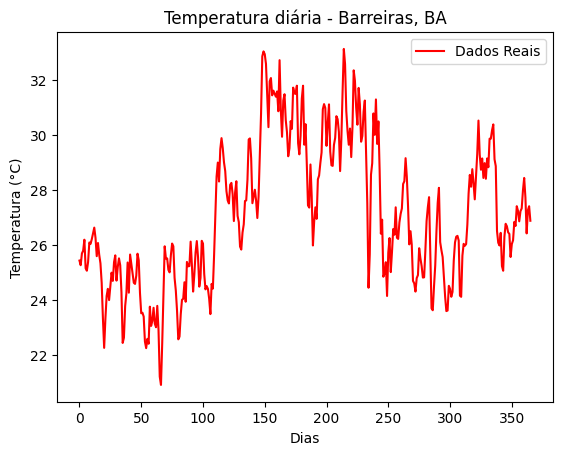

In [5]:
# Plot dataset
x = range(len(temp))
plt.plot(x, temp, 'r-', label='Dados Reais')
plt.title('Temperatura diária - Barreiras, BA')
#plt.axis([-1, 52, 2000.0, 16000.0])
plt.xlabel('Dias')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

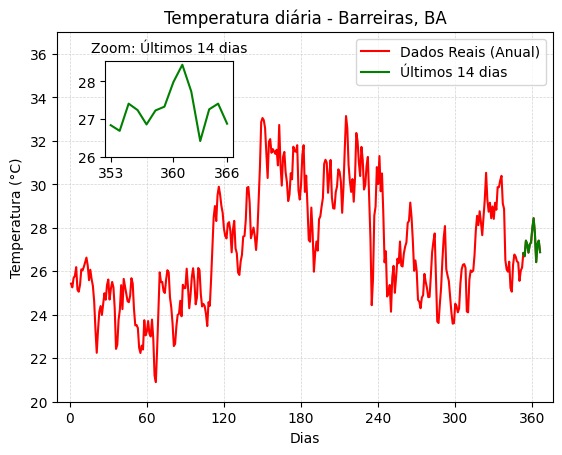

In [6]:
import matplotlib.pyplot as plt

# Criando os valores do eixo X de 1 a 366
x = range(1, len(temp) + 1)  # Agora x começa de 1 e vai até len(temp)

# Últimos 14 dias
x_recent = x[-14:]
temp_recent = temp[-14:]

# Criando a figura e os eixos
fig, ax = plt.subplots()

# Plotando o gráfico principal com a linha vermelha para os dados reais
ax.plot(x, temp, 'r-', label='Dados Reais (Anual)')

# Destacando os últimos 14 dias em verde e linha contínua
ax.plot(x_recent, temp_recent, 'g-', linewidth=1.5, label='Últimos 14 dias')

# Título e configuração dos eixos
ax.set_title('Temperatura diária - Barreiras, BA')
ax.set_xlabel('Dias')
ax.set_ylabel('Temperatura (°C)')
ax.set_xticks(range(0, 367, 60))  # Marcação no eixo X a cada 60 dias
ax.set_yticks([round(i, 1) for i in range(20, 37, 2)])  # Valores do eixo Y mais espaçados

# Aumentando o limite superior do eixo Y para caber o zoom
ax.set_ylim(20, 37)

# Adicionando grade
ax.grid(True, which='both', axis='both', color='lightgray', linestyle='--', linewidth=0.5)

# Ajuste dos limites dos eixos
ax.set_xlim(-10, 376)  # Limitar o gráfico de 1 a 366

# Criando o zoom, ajustando 1 grau para cima
ax_inset = fig.add_axes([0.2, 0.62, 0.2, 0.2])  # Ajuste do zoom para mais 1 grau para cima
ax_inset.plot(x_recent, temp_recent, 'g-', linewidth=1.5)  # Linha do zoom verde
ax_inset.set_title("Zoom: Últimos 14 dias", fontsize=10)

# Ajustando os valores do eixo X e Y do zoom
ax_inset.set_xticks([x_recent[0], x_recent[len(x_recent) // 2], x_recent[-1]])  # Apenas 3 valores no eixo X
ax_inset.set_yticks(range(int(min(temp_recent)), int(max(temp_recent)) + 1, 1))  # Mais valores no eixo Y

# Removendo a grade do zoom
ax_inset.grid(False)

# Exibir o gráfico
ax.legend()
plt.show()

In [7]:
## Plot naive prediction
#test_output = test_sales[MIN:]
#naive_prediction = test_sales[MIN-1:-1]
#x = range(len(test_output))
#plt.plot(x, test_output, 'g-', label='test_output')
#plt.plot(x, naive_prediction, 'm-', label='naive prediction')
#plt.title('Book store sales')
##plt.axis([0, len(test_output), 0.0, 3000.0])
#plt.xlabel('months')
#plt.ylabel('Monthly book store sales')
#plt.legend()
#plt.show()

The next step is to standardize the data points by subtracting the mean and dividing by the standard deviation of the training examples.


In [8]:
# Standardize train and test data.
# Use only training seasons to compute mean and stddev.
mean = np.mean(train_sales)
stddev = np.std(train_sales)
train_sales_std = (train_sales - mean)/stddev
test_sales_std = (test_sales - mean)/stddev

mean0 = np.mean(train_sales0)
stddev0 = np.std(train_sales0)
train_sales_std0 = (train_sales0 - mean0)/stddev0
test_sales_std0 = (test_sales0 - mean0)/stddev0

mean1 = np.mean(train_sales1)
stddev1 = np.std(train_sales1)
train_sales_std1 = (train_sales1 - mean1)/stddev1
test_sales_std1 = (test_sales1 - mean1)/stddev1

mean2 = np.mean(train_sales2)
stddev2 = np.std(train_sales2)
train_sales_std2 = (train_sales2 - mean2)/stddev2
test_sales_std2 = (test_sales2 - mean2)/stddev2

mean3 = np.mean(train_sales3)
stddev3 = np.std(train_sales3)
train_sales_std3 = (train_sales3 - mean3)/stddev3
test_sales_std3 = (test_sales3 - mean3)/stddev3

mean4 = np.mean(train_sales4)
stddev4 = np.std(train_sales4)
train_sales_std4 = (train_sales4 - mean4)/stddev4
test_sales_std4 = (test_sales4 - mean4)/stddev4

mean5 = np.mean(train_sales5)
stddev5 = np.std(train_sales5)
train_sales_std5 = (train_sales5 - mean5)/stddev5
test_sales_std5 = (test_sales5 - mean5)/stddev5


In our previous examples, the datasets were already organized into individual examples. For example, we had an array of images serving as input values and an associated array of classes serving as expected output values. However, the data that we created in this example is raw historical data and not yet organized as a set of training and test examples (see the section in the book for an illustration of how we need it organized). This is the next step in our code example. The code snippet below allocates tensors for the training data and initializes all entries to 0. It then loops through the historical data and creates training examples, then does the same thing with the test data.

In [9]:
test_sales_std

array([-0.08974112, -0.14625049,  0.12499489,  0.06095076, -0.08220635,
        0.05718337,  0.09485652,  0.3397309 ,  0.5130271 ,  0.2455484 ,
       -0.24796776,  0.06848553,  0.12499489, -0.07467229], dtype=float32)

In [10]:
# Create train examples.valores
train_days = len(train_sales)
train_X = np.zeros((train_days, train_days, 6), dtype=np.float32)
train_y = np.zeros((train_days, 1), dtype=np.float32)
for i in range(0, train_days):
    #train_X[i, -(i+MIN):, 0] = train_sales_std[0:i+MIN]
    train_X[i, -(i+MIN):, 0] = train_sales_std0[0:i+MIN]
    train_X[i, -(i+MIN):, 1] = train_sales_std1[0:i+MIN]
    train_X[i, -(i+MIN):, 2] = train_sales_std2[0:i+MIN]
    train_X[i, -(i+MIN):, 3] = train_sales_std3[0:i+MIN]
    train_X[i, -(i+MIN):, 4] = train_sales_std4[0:i+MIN]
    train_X[i, -(i+MIN):, 5] = train_sales_std5[0:i+MIN]
    train_y[i, 0] = train_sales_std[i]

# Create test examples.
test_days = len(test_sales)
test_X = np.zeros((test_days, test_days, 6), dtype=np.float32)
test_y = np.zeros((test_days, 1), dtype=np.float32)
for i in range(0, test_days):
    #test_X[i, -(i+MIN):, 0] = test_sales_std[0:i+MIN]
    test_X[i, -(i+MIN):, 0] = test_sales_std0[0:i+MIN]
    test_X[i, -(i+MIN):, 1] = test_sales_std1[0:i+MIN]
    test_X[i, -(i+MIN):, 2] = test_sales_std2[0:i+MIN]
    test_X[i, -(i+MIN):, 3] = test_sales_std3[0:i+MIN]
    test_X[i, -(i+MIN):, 4] = test_sales_std4[0:i+MIN]
    test_X[i, -(i+MIN):, 5] = test_sales_std5[0:i+MIN]
    test_y[i, 0] = test_sales_std[i]

In [11]:
#train_X[39]

We are finally ready to define and train our network. This is shown in the code snippet below.

In [12]:
# Create RNN model
model = Sequential()
model.add(SimpleRNN(256, activation='relu',
                    input_shape=(None, 6)))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_absolute_error', optimizer = 'adam') #,metrics =['mean_absolute_error'])
model.summary()
#history = model.fit(train_X, train_y,
#                    validation_data
#                    = (test_X, test_y), epochs=EPOCHS,
#                    batch_size=BATCH_SIZE, verbose=2,
#                    shuffle=True)

re=ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='min', min_lr=0.00001)
history = model.fit(train_X, train_y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, callbacks=[re], verbose=1)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 256)               67328     
                                                                 
 dense (Dense)               (None, 1)                 257       
                                                                 
Total params: 67,585
Trainable params: 67,585
Non-trainable params: 0
_________________________________________________________________
Epoch 1/500
32/32 [==============================] - 2s 44ms/step - loss: 0.2305 - val_loss: 0.1235 - lr: 0.0010
Epoch 2/500
32/32 [==============================] - 1s 40ms/step - loss: 0.1106 - val_loss: 0.2025 - lr: 0.0010
Epoch 3/500
32/32 [==============================] - 2s 48ms/step - loss: 0.1087 - val_loss: 0.0906 - lr: 0.0010
Epoch 4/500
32/32 [==============================] - 1s 43ms/step - loss: 0.0911 - val_loss: 0.1114 - lr: 0.0

For comparison, create naive predictions based on standardized data.

In [13]:
# Create naive prediction based on standardized data.
test_output = test_sales_std[MIN:]
naive_prediction = test_sales_std[MIN-1:-1]
mean_squared_error = np.mean(np.square(naive_prediction
                                       - test_output))
mean_abs_error = np.mean(np.abs(naive_prediction
                                - test_output))
print('naive test mse: ', mean_squared_error)
print('naive test mean abs: ', mean_abs_error)

naive test mse:  0.051577903
naive test mean abs:  0.18952416


1/1 [==============================] - 0s 238ms/step


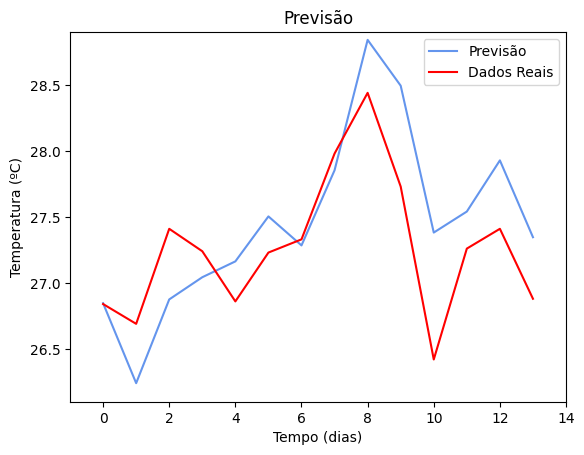

In [14]:

# Use trained model to predict the test data
predicted_test = model.predict(test_X)  # Removido len(test_X) se não for necessário
predicted_test = np.reshape(predicted_test, (len(predicted_test)))
predicted_test = predicted_test * stddev + mean

# Plot test prediction
x = np.arange(len(test_sales))  # Garante alinhamento correto dos índices

plt.plot(x, predicted_test, color='cornflowerblue', label='Previsão')  # Correção da linha
plt.plot(x, test_sales[-len(test_sales):], color='red', label='Dados Reais')  # Correção da vírgula extra

# plt.title('Book sales')
plt.axis([-1, 14, 26.1, 28.9])
plt.title('Previsão')
plt.xlabel('Tempo (dias)')
plt.ylabel('Temperatura (ºC)')  # Verifique se "Temperatura" faz sentido no contexto de vendas de livros
plt.legend()
plt.show()

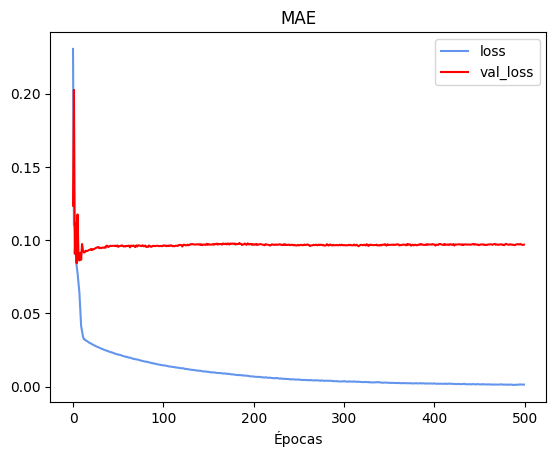

In [15]:
plt.plot(history.history['loss'], color='cornflowerblue',
         label='loss')
plt.plot(history.history['val_loss'], color='red',
         label='val_loss')
plt.title('MAE')
#plt.axis([-1, 12, 2000.0, 16000.0])
plt.xlabel('Épocas')
# plt.ylabel('MAE')
plt.legend()
plt.show()

In [16]:
predicted_test

array([26.846127, 26.240524, 26.875027, 27.043144, 27.163177, 27.503923,
       27.28421 , 27.853369, 28.841364, 28.494034, 27.381517, 27.540756,
       27.928411, 27.346321], dtype=float32)

In [17]:
test_sales

array([26.84, 26.69, 27.41, 27.24, 26.86, 27.23, 27.33, 27.98, 28.44,
       27.73, 26.42, 27.26, 27.41, 26.88], dtype=float32)

In [18]:
sum = 0
for i in range(len(test_sales)):
    sum += (abs(predicted_test[i] - test_sales[i]))

mae = sum/14
mae

0.3806683676583426

In [19]:
print(history.history['loss'])

[0.2304914891719818, 0.11055745929479599, 0.10869752615690231, 0.09109187126159668, 0.08242473751306534, 0.07758542150259018, 0.07147377729415894, 0.06462886929512024, 0.052308063954114914, 0.04125702381134033, 0.03778849542140961, 0.03424154222011566, 0.03233138099312782, 0.03216547146439552, 0.03151252493262291, 0.031178422272205353, 0.03086935169994831, 0.030350500717759132, 0.02995082177221775, 0.029732733964920044, 0.02930613048374653, 0.02889961749315262, 0.028676174581050873, 0.028300948441028595, 0.027937231585383415, 0.027692589908838272, 0.027351321652531624, 0.027065059170126915, 0.02682335488498211, 0.02651081420481205, 0.02632797881960869, 0.025924351066350937, 0.02572132647037506, 0.025518912822008133, 0.025180315598845482, 0.025003349408507347, 0.02475232630968094, 0.02447698824107647, 0.024465827271342278, 0.024011630564928055, 0.02386564016342163, 0.023631205782294273, 0.023457851260900497, 0.02323734760284424, 0.023150190711021423, 0.022790197283029556, 0.022584939375

In [20]:
print(history.history['val_loss'])

[0.12349387258291245, 0.20252399146556854, 0.09063674509525299, 0.11143209040164948, 0.08417776226997375, 0.11749442666769028, 0.08949150145053864, 0.08606698364019394, 0.09135721623897552, 0.08657053858041763, 0.09729357808828354, 0.0928075835108757, 0.09157669544219971, 0.09163454174995422, 0.09275546669960022, 0.09243331849575043, 0.0926426500082016, 0.09296364337205887, 0.09331229329109192, 0.09347362816333771, 0.09392914175987244, 0.0931207463145256, 0.09379783272743225, 0.0937560498714447, 0.09411559253931046, 0.09449008107185364, 0.09485621005296707, 0.09502925723791122, 0.09525833278894424, 0.09448625892400742, 0.09480765461921692, 0.0945148766040802, 0.09470003843307495, 0.09490278363227844, 0.0947643518447876, 0.09508638828992844, 0.09475371986627579, 0.09617182612419128, 0.09600469470024109, 0.09526655077934265, 0.09566587954759598, 0.09610087424516678, 0.09599807858467102, 0.0960686132311821, 0.09606431424617767, 0.09610532224178314, 0.09594845771789551, 0.09619900584220886